**MAIN GOAL** : Cluster loyal versus disengaged customers by behavioral and financial 
attributes. Mine rules such as: customers from Germany holding only one 
product who are inactive represent a strong churn profile. Detect anomalies 
in sudden balance drops preceding account closure.


# Phase 1 : Data Understanding and Preprocessing

P1 Goal : Produce a clean, analysis-ready dataset and document every preprocessing 
decision with justification. This phase establishes the factual foundation for all 
subsequent mining steps

## EDA

### Importing libraries and loading dataset

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv('../data/raw/churn.csv')

### Data Types and Missing Values

In [60]:
# data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [61]:
# missing value
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [62]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Check unique values for object data

In [63]:
print( "Surname Unique counts:", df['Surname'].value_counts())


Surname Unique counts: Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
            ..
Izmailov     1
Bold         1
Bonham       1
Poninski     1
Burbidge     1
Name: count, Length: 2932, dtype: int64


In [64]:
print("Geography Unique counts:", df['Geography'].value_counts())

Geography Unique counts: Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


In [65]:
print("Gender counts:", df['Gender'].value_counts())

Gender counts: Gender
Male      5457
Female    4543
Name: count, dtype: int64


### Outlier detection

In [66]:
# Note: We identify outliers but do not drop them here, as Phase 4 
# requires cross-referencing anomalies with Phase 2 cluster outliers.

numeric_cols = df.select_dtypes(include=['number']).columns
cols_to_check = [col for col in numeric_cols if col not in ['RowNumber', 'CustomerId', 'HasCrCard', 'IsActiveMember', 'Exited']]

def detect_outliers_iqr(data, columns):
    outlier_indices = []
    
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index
        outlier_indices.extend(outliers)
        
        print(f"Column: {col} | Outliers detected: {len(outliers)}")
        
    return list(set(outlier_indices))

outlier_list = detect_outliers_iqr(df, cols_to_check)
outlier_df = df.loc[outlier_list]

Column: CreditScore | Outliers detected: 15
Column: Age | Outliers detected: 359
Column: Tenure | Outliers detected: 0
Column: Balance | Outliers detected: 0
Column: NumOfProducts | Outliers detected: 60
Column: EstimatedSalary | Outliers detected: 0


### Graph Distribution of numerical features

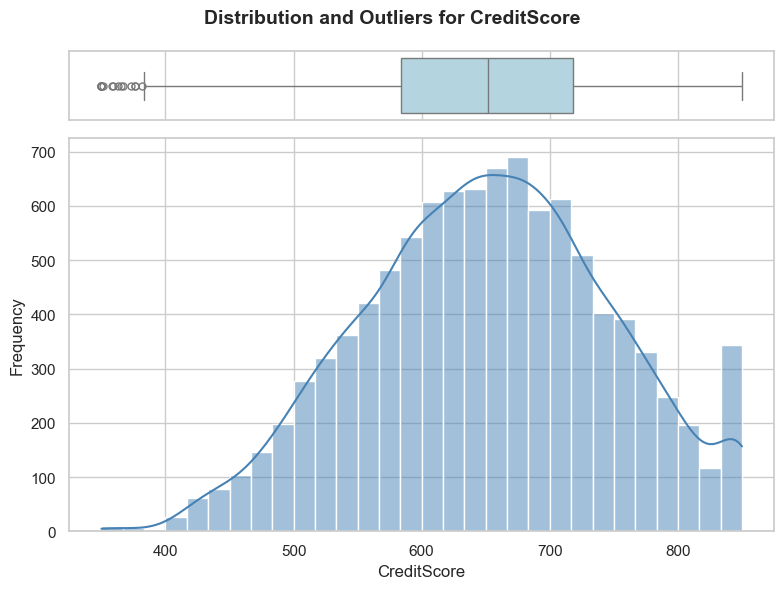

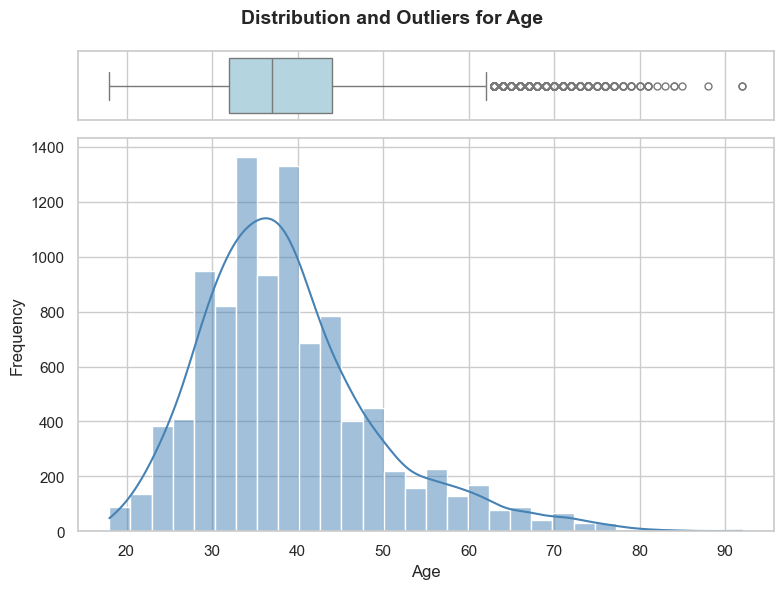

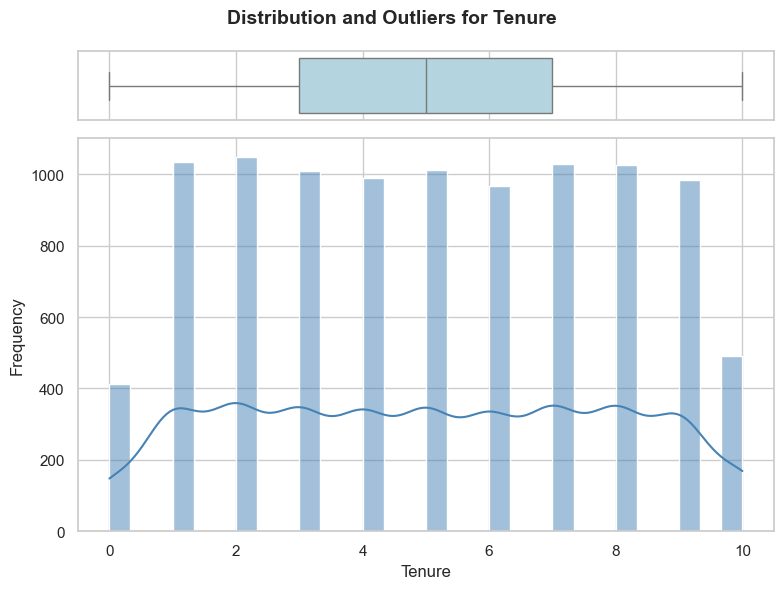

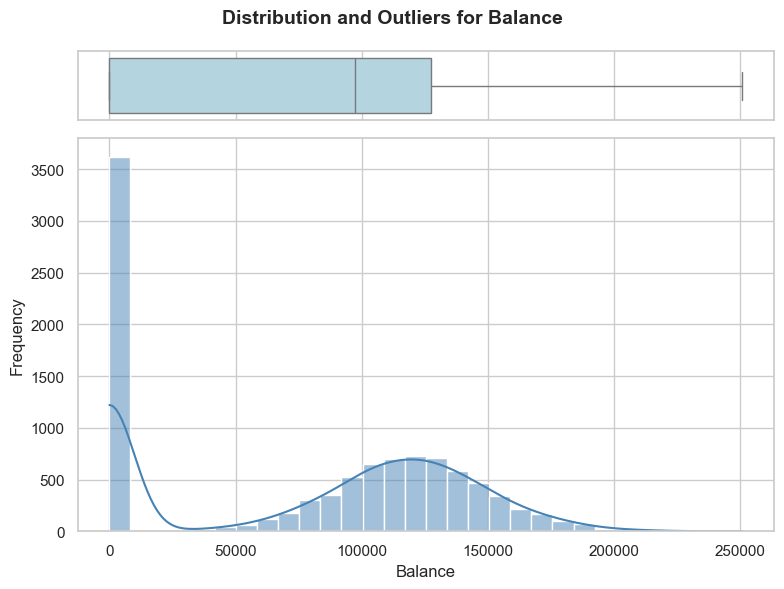

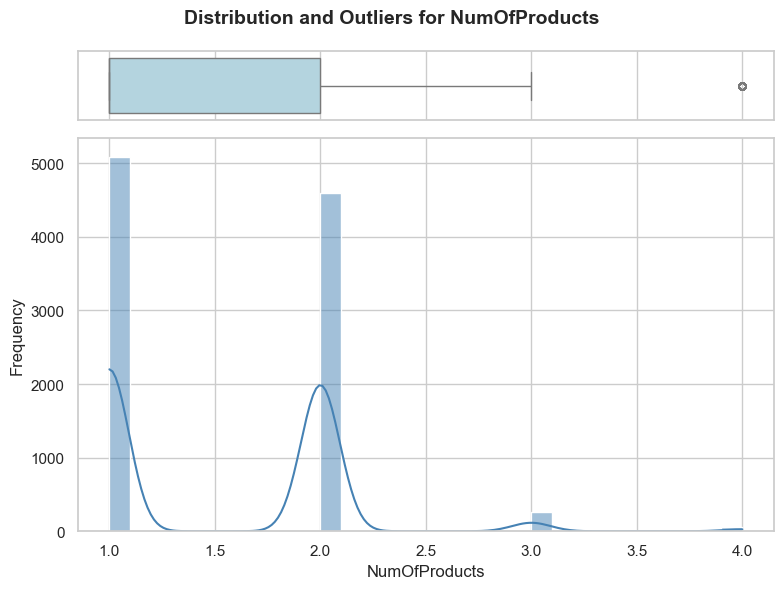

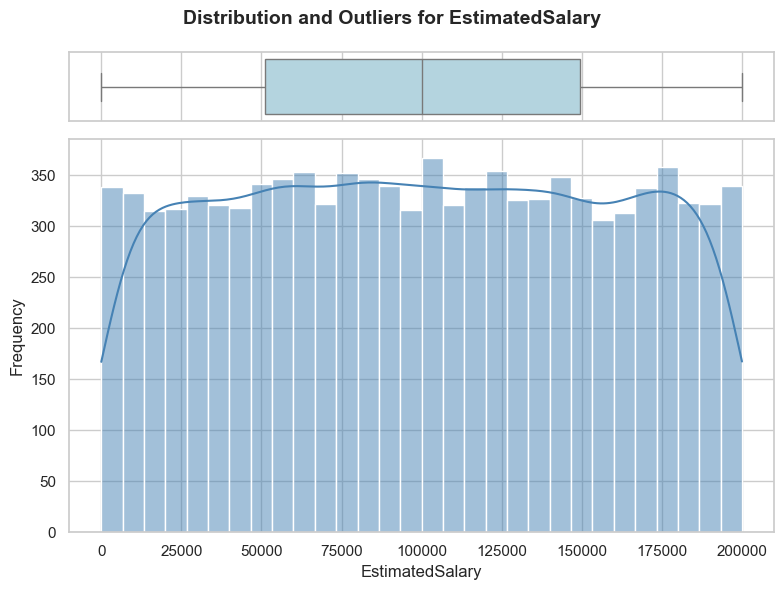

In [67]:
# 1. Define your numerical columns (excluding IDs and binary flags)
cols_to_check = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# 2. Set the visual style
sns.set_theme(style="whitegrid")

# 3. Loop through each column and create a combined graph
for col in cols_to_check:
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)}, 
                                          figsize=(8, 6))
    
    sns.boxplot(x=df[col], ax=ax_box, color='lightblue', flierprops=dict(marker='o', color='red', markersize=5))
    sns.histplot(data=df, x=col, kde=True, ax=ax_hist, color='steelblue', bins=30)
    
    ax_box.set(xlabel='') 
    ax_hist.set(xlabel=col, ylabel='Frequency')
    
    plt.suptitle(f'Distribution and Outliers for {col}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Graph Count of object features

C:\Users\Thomas\AppData\Local\Temp\ipykernel_100680\2446648625.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


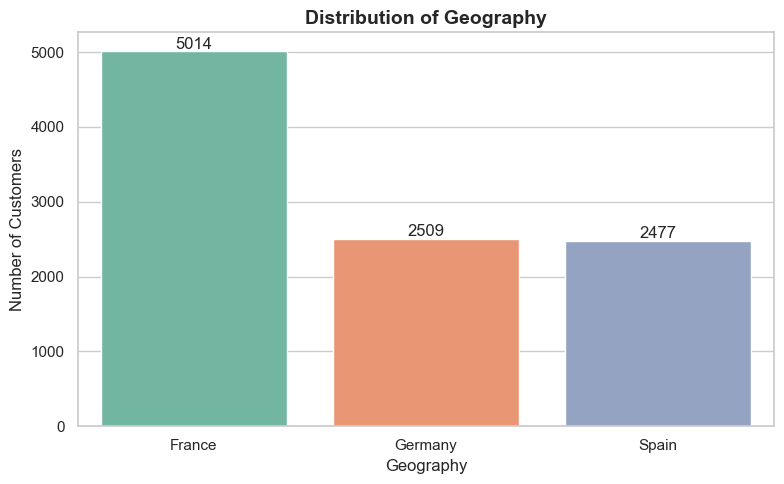

C:\Users\Thomas\AppData\Local\Temp\ipykernel_100680\2446648625.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


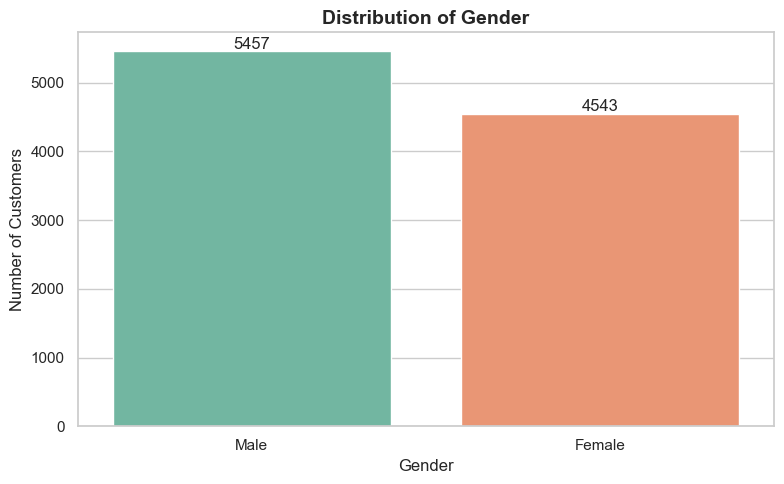

In [68]:
object_cols = df.select_dtypes(include=['object']).columns
cols_to_exclude = ['RowNumber', 'CustomerId', 'Surname']
cols_to_plot = [col for col in object_cols if col not in cols_to_exclude]

sns.set_theme(style="whitegrid")

for col in cols_to_plot:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
    
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 5), 
                    textcoords='offset points')
    
    plt.tight_layout()
    plt.show()

## Apply data cleaning

In [69]:
# Step 1: Basic Cleaning
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df_clean.drop_duplicates(inplace=True)
df_clean.dropna(inplace=True)

print("Dataset shape after cleaning:", df_clean.shape)
df_clean.head()

Dataset shape after cleaning: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Conduct feature selection using correlation analysis and entropy measures

### Pearson Correlation Heatmap and Feature Redundancy Analysis

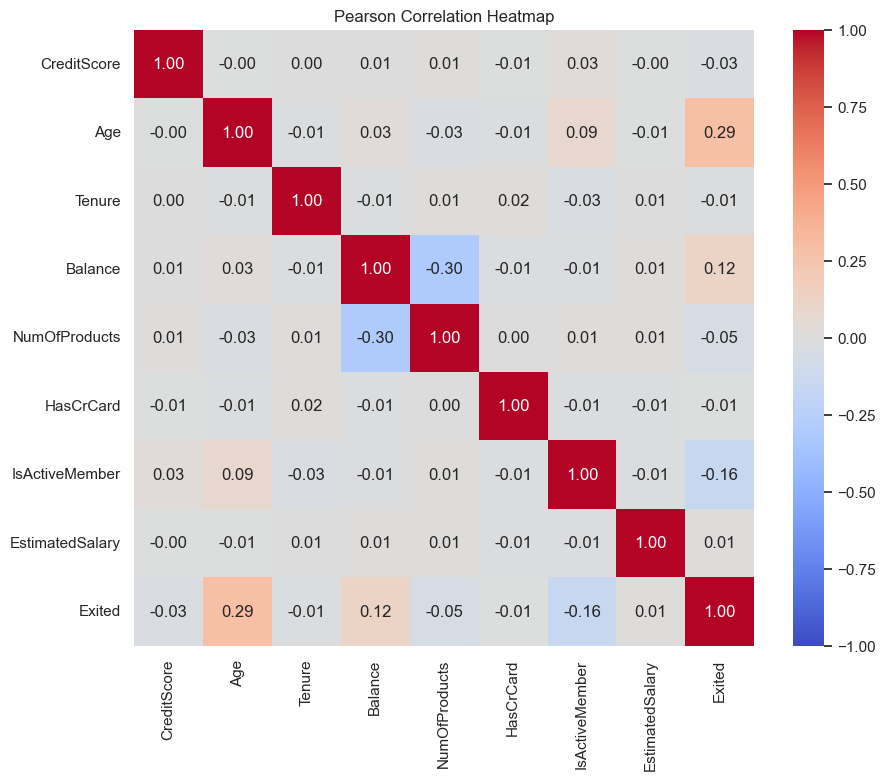

In [70]:
# Pearson Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
numeric_cols = df_clean.select_dtypes(include=['number'])
correlation_matrix = numeric_cols.corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Pearson Correlation Heatmap')
plt.show()

In [71]:
# UNSUPERVISED Feature Redundancy Analysis
# Instead of supervised mutual_info_classif (which requires a target label),
# we analyze pairwise Pearson correlations to identify redundant features.
# This is appropriate for unsupervised discovery tasks.
import numpy as np

corr_matrix = numeric_cols.corr(method='pearson').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Flag pairs with correlation > 0.85
threshold = 0.85
high_corr_pairs = []
for col in upper_tri.columns:
    for row in upper_tri.index:
        val = upper_tri.loc[row, col]
        if pd.notna(val) and val > threshold:
            high_corr_pairs.append((row, col, val))

if high_corr_pairs:
    print(f'Highly correlated feature pairs (r > {threshold}):')
    for f1, f2, r in high_corr_pairs:
        print(f'  {f1} <-> {f2}: r = {r:.3f}')
else:
    print(f'No highly correlated feature pairs found (threshold: {threshold})')
    print('All features provide independent information - suitable for clustering.')


No highly correlated feature pairs found (threshold: 0.85)
All features provide independent information - suitable for clustering.


#### EDA: Distribution of the 'Exited' Feature

Note: This is exploratory analysis of the Exited feature distribution,
not a supervised class-imbalance diagnostic. In our unsupervised pipeline,
Exited is treated as just another feature for pattern discovery.

C:\Users\Thomas\AppData\Local\Temp\ipykernel_100680\2829317231.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Exited', palette='Set1')


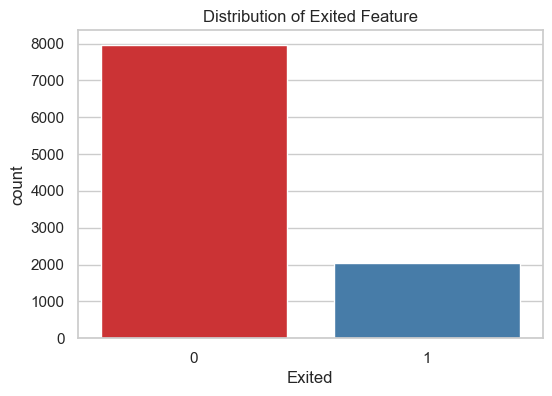

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [72]:
# EDA: Distribution of the Exited feature (not a target variable)
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='Exited', palette='Set1')
plt.title('Distribution of Exited Feature')
plt.show()

# Print percentages
print(df_clean['Exited'].value_counts(normalize=True) * 100)

## Perform data transformation: normalization, encoding, and binning of continuous variables

In [73]:
from sklearn.preprocessing import StandardScaler
import os

# Create directory if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# Path A: The Distance Matrix (For K-Means & Isolation Forest)
df_matrix = df_clean.copy()

# Scale Numericals: StandardScaler (Z-score)
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()
df_matrix[num_cols] = scaler.fit_transform(df_matrix[num_cols])

# Encode Categoricals: One-Hot Encoding
df_matrix = pd.get_dummies(df_matrix, columns=['Geography', 'Gender'], drop_first=True)

# Save Path A output
matrix_path = '../data/processed/churn_clustering_matrix.csv'
df_matrix.to_csv(matrix_path, index=False)
print(f"Distance Matrix saved to {matrix_path}")

df_matrix.head()

Distance Matrix saved to ../data/processed/churn_clustering_matrix.csv


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,1,1,0.021886,1,False,False,False
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,0,1,0.216534,0,False,True,False
2,-1.536794,0.293517,1.032908,1.333053,2.527057,1,0,0.240687,1,False,False,False
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,0,0,-0.108918,0,False,False,False
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,1,1,-0.365276,0,False,True,False


In [74]:
# Path B: The Transaction Matrix (For Apriori)
df_trans = df_clean.copy()

# Bin Numericals (Discretize) — ALL numericals must be categorical for Apriori
df_trans['Age'] = pd.cut(df_trans['Age'], bins=[0, 25, 60, 150], labels=['Youth', 'Adult', 'Senior'])

# Balance: Zero Balance, Low, Medium, High
balance_bins = [-1, 0, 50000, 100000, float('inf')]
balance_labels = ['Zero Balance', 'Low', 'Medium', 'High']
df_trans['Balance'] = pd.cut(df_trans['Balance'], bins=balance_bins, labels=balance_labels)

# CreditScore: Poor, Fair, Good, Excellent
df_trans['CreditScore'] = pd.qcut(df_trans['CreditScore'], q=4, labels=['Poor', 'Fair', 'Good', 'Excellent'])

# Tenure: Short, Medium, Long, VeryLong (FIX: was previously left as raw integer)
df_trans['Tenure'] = pd.cut(df_trans['Tenure'], bins=[-1, 2, 5, 8, 10],
                            labels=['Short', 'Medium', 'Long', 'VeryLong'])

# NumOfProducts: convert to labeled string (FIX: was previously left as raw integer)
df_trans['NumOfProducts'] = df_trans['NumOfProducts'].astype(str) + ' Products'

# EstimatedSalary: quartile bins (FIX: was previously left as raw float)
df_trans['EstimatedSalary'] = pd.qcut(df_trans['EstimatedSalary'], q=4,
                                      labels=['LowSalary', 'MidLowSalary', 'MidHighSalary', 'HighSalary'])

# Strings kept as they are (Geography, Gender)

# Map Binary Flags
df_trans['HasCrCard'] = df_trans['HasCrCard'].map({0: "No Credit Card", 1: "Has Credit Card"})
df_trans['IsActiveMember'] = df_trans['IsActiveMember'].map({0: "Inactive", 1: "Active"})

# Map Target
df_trans['Exited'] = df_trans['Exited'].map({0: "Retained", 1: "Churned"})

# Save Path B output
trans_path = '../data/processed/churn_transactions.csv'
df_trans.to_csv(trans_path, index=False)
print(f"Transaction Matrix saved to {trans_path}")

df_trans.head()


Transaction Matrix saved to ../data/processed/churn_transactions.csv


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,Fair,France,Female,Adult,Short,Zero Balance,1 Products,Has Credit Card,Active,MidHighSalary,Churned
1,Fair,Spain,Female,Adult,Short,Medium,1 Products,No Credit Card,Active,MidHighSalary,Retained
2,Poor,France,Female,Adult,Long,High,3 Products,Has Credit Card,Inactive,MidHighSalary,Churned
3,Good,France,Female,Adult,Short,Zero Balance,2 Products,No Credit Card,Inactive,MidLowSalary,Retained
4,Excellent,Spain,Female,Adult,Short,High,1 Products,Has Credit Card,Active,MidLowSalary,Retained


## Deliverable: Clean dataset file and Preprocessing Report

In [75]:
# Export cleaned data
clean_data_path = '../data/processed/churn_clean.csv'
df_clean.to_csv(clean_data_path, index=False)
print(f"Clean data saved to {clean_data_path}")

Clean data saved to ../data/processed/churn_clean.csv


# Phase 2: Segmentation via Clustering

## Initialize cluster

In [76]:
# ============================================================
# Phase 2 – Segmentation via Clustering (KDD Pipeline)
# ============================================================
# Input  : ../data/processed/churn_clustering_matrix.csv
# Content: StandardScaled numericals, OHE categoricals,
#          raw binary flags, and the target 'Exited'.
# Goal   : Unsupervised discovery of customer segments.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# ── Step 1: Load data & isolate the target variable ──────────
df_cluster = pd.read_csv('../data/processed/churn_clustering_matrix.csv')

# CRITICAL: Separate the target column BEFORE any clustering.
# 'Exited' is the ground-truth churn label – it must NOT
# influence the unsupervised segmentation.
y_exited = df_cluster['Exited'].copy()
X_cluster = df_cluster.drop(columns=['Exited']).copy()

print(f'Clustering feature matrix shape : {X_cluster.shape}')
print(f'Target variable (Exited) shape  : {y_exited.shape}')
print(f'Features used for clustering    : {list(X_cluster.columns)}')

Clustering feature matrix shape : (10000, 11)
Target variable (Exited) shape  : (10000,)
Features used for clustering    : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


## Determine optimal K using the Elbow Method and Silhouette Score

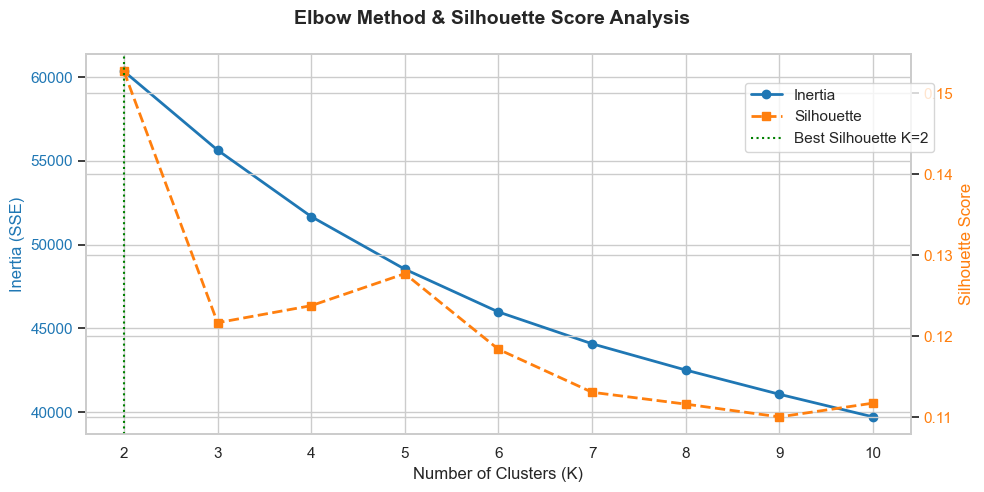


Optimal K by Silhouette Score: 2
Silhouette scores: {2: 0.1527, 3: 0.1217, 4: 0.1238, 5: 0.1277, 6: 0.1184, 7: 0.1131, 8: 0.1116, 9: 0.1101, 10: 0.1118}


In [77]:
# ── Step 2: Determine optimal K (Elbow + Silhouette) ────────
K_RANGE = range(2, 11)
inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

# ── Dual-axis chart ──────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))

color_inertia = '#1f77b4'
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (SSE)', color=color_inertia, fontsize=12)
ax1.plot(list(K_RANGE), inertias, 'o-', color=color_inertia, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color_inertia)

ax2 = ax1.twinx()
color_sil = '#ff7f0e'
ax2.set_ylabel('Silhouette Score', color=color_sil, fontsize=12)
ax2.plot(list(K_RANGE), silhouettes, 's--', color=color_sil, linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color_sil)

# Mark the best silhouette K
best_k = list(K_RANGE)[np.argmax(silhouettes)]
ax2.axvline(x=best_k, color='green', linestyle=':', linewidth=1.5,
            label=f'Best Silhouette K={best_k}')

fig.suptitle('Elbow Method & Silhouette Score Analysis', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.85))
fig.tight_layout()
plt.show()

print(f'\nOptimal K by Silhouette Score: {best_k}')
print(f'Silhouette scores: {dict(zip(K_RANGE, [round(s, 4) for s in silhouettes]))}')


## Apply K-Means clustering to segment entities by behavioral or financial attributes


── K = 3 ──────────────────────────────────────
  Inertia (SSE)    : 55,646.51
  Silhouette Score : 0.1217
  Cluster sizes    :
0    3132
1    3699
2    3169

  Churn rate per cluster:
         total  churned  churn_rate_%
Cluster                              
0         3132      714         22.80
1         3699      572         15.46
2         3169      751         23.70

── K = 4 ──────────────────────────────────────
  Inertia (SSE)    : 51,679.25
  Silhouette Score : 0.1238
  Cluster sizes    :
0    1317
1    3212
2    2705
3    2766

  Churn rate per cluster:
         total  churned  churn_rate_%
Cluster                              
0         1317      586         44.50
1         3212      389         12.11
2         2705      540         19.96
3         2766      522         18.87

── K = 5 ──────────────────────────────────────
  Inertia (SSE)    : 48,535.39
  Silhouette Score : 0.1277
  Cluster sizes    :
0    1083
1    2023
2    2045
3    2873
4    1976

  Churn rate per clu

c:\Users\Thomas\Documents\Project_DATAMINING\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\Thomas\Documents\Project_DATAMINING\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\Thomas\Documents\Project_DATAMINING\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


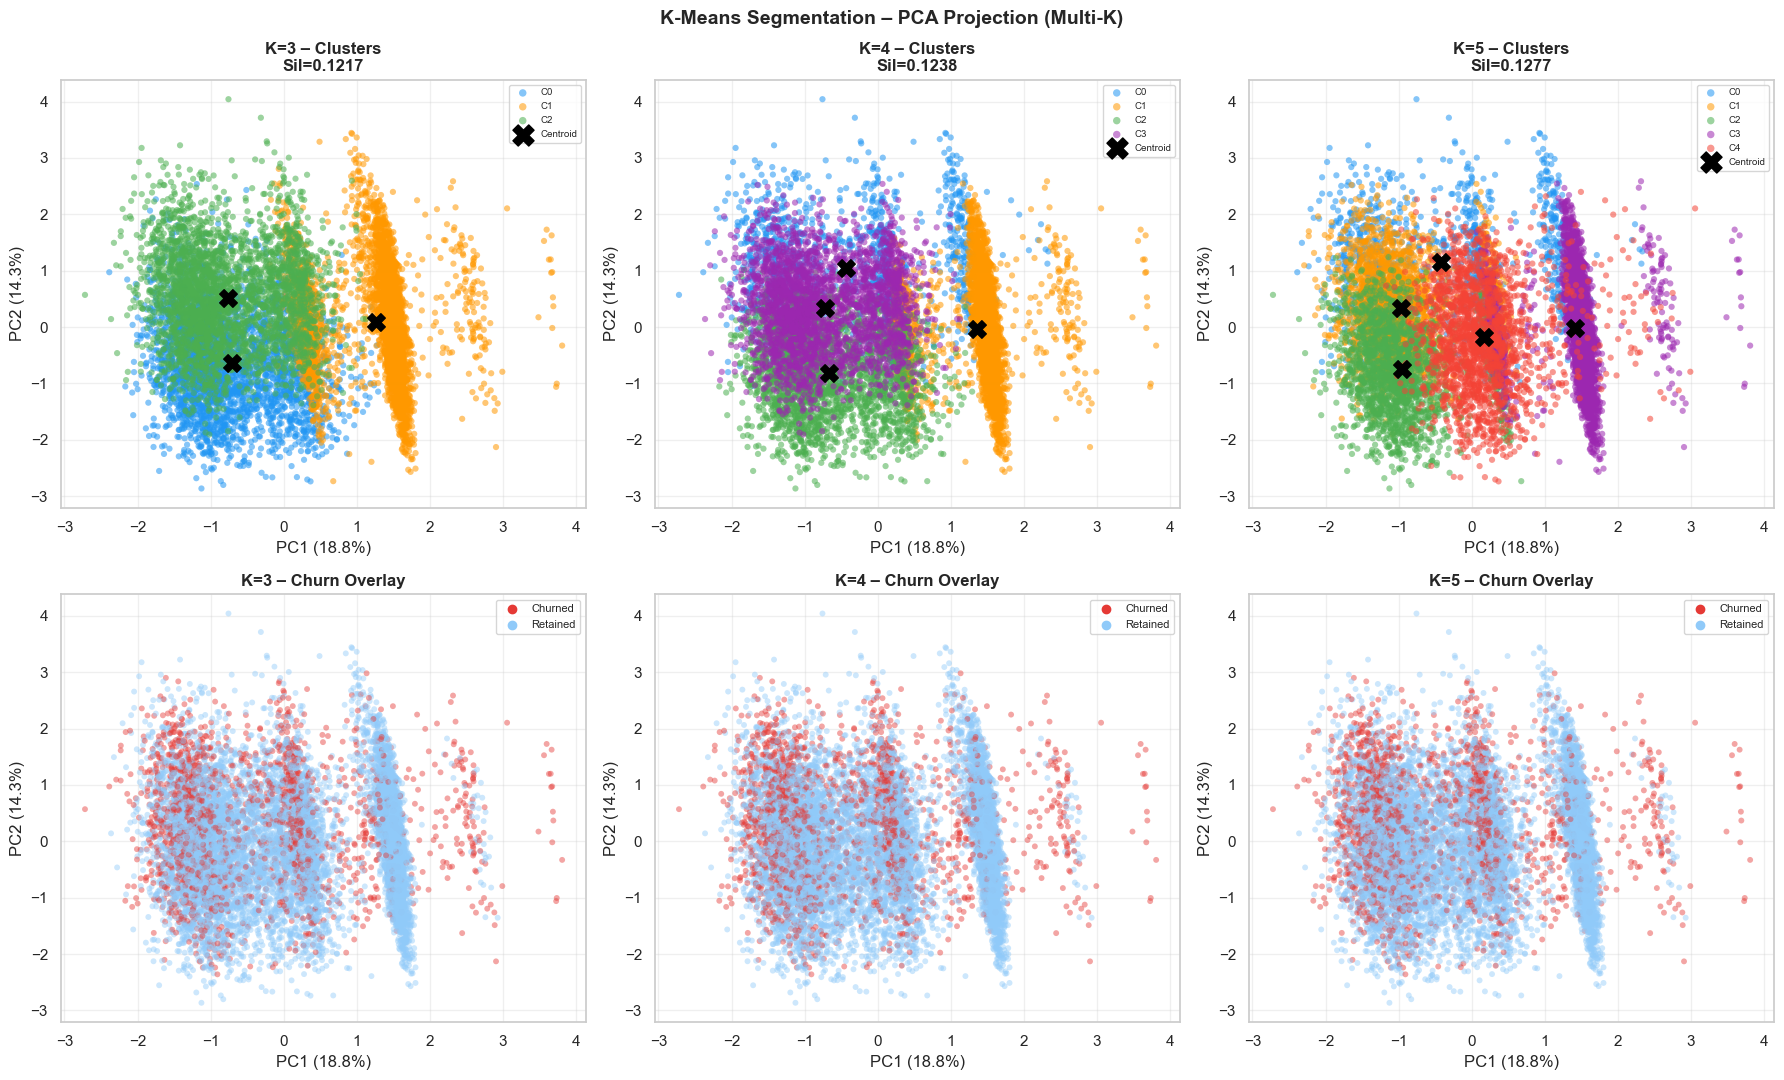

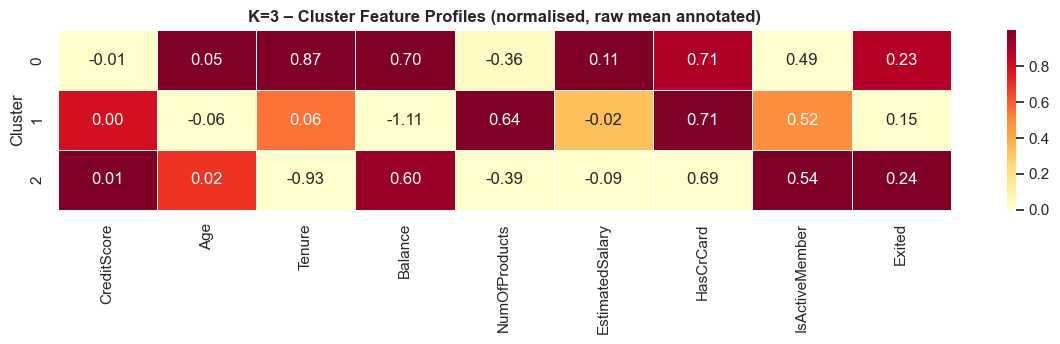

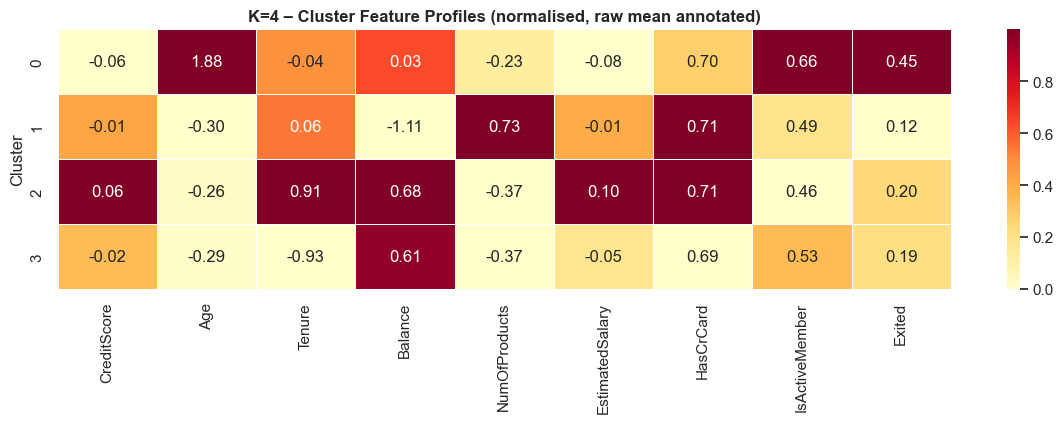

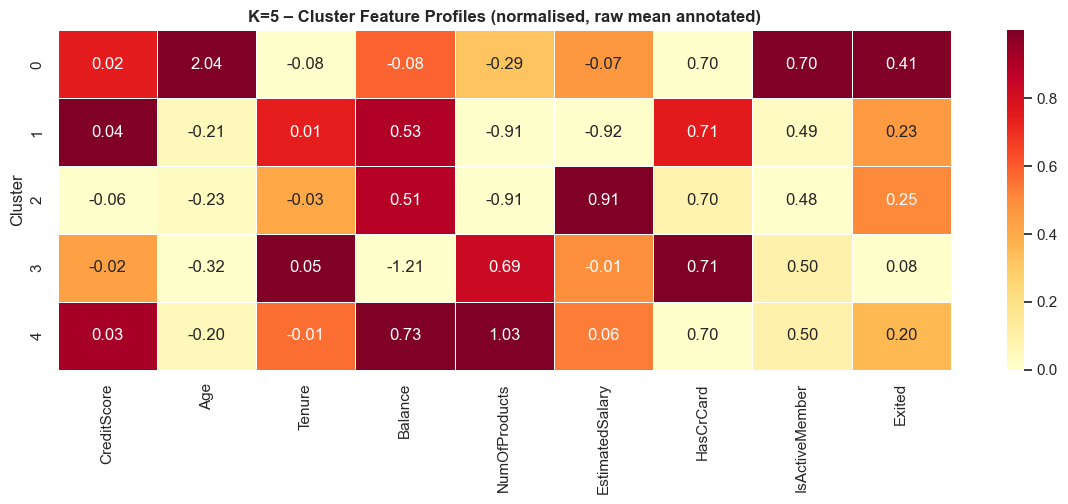

✔ K=3 dataset saved → ../data/processed/churn_clustered_K3.csv
✔ K=4 dataset saved → ../data/processed/churn_clustered_K4.csv
✔ K=5 dataset saved → ../data/processed/churn_clustered_K5.csv

💡 Recommended K by Silhouette Score: K=5


In [78]:
# ============================================================
# Phase 2 – Step 2: K-Means Clustering Segmentation (Multi-K)
# ============================================================

from sklearn.decomposition import PCA

# ── Configuration ─────────────────────────────────────────────
OPTIMAL_K_LIST = [3, 4, 5]   # ← change freely, e.g. [2, 3, 4, 5]
RANDOM_STATE   = 42

# ── Helper: run one full K-Means pass ────────────────────────
def run_kmeans(X, k, random_state=42):
    """Fit KMeans, return (model, labels, inertia, silhouette)."""
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=random_state
    )
    labels = km.fit_predict(X)
    sil    = silhouette_score(X, labels)
    return km, labels, km.inertia_, sil


# ── Step 2a: Fit K-Means for every K in OPTIMAL_K_LIST ───────
results = {}   # keyed by k

print("=" * 55)
for k in OPTIMAL_K_LIST:
    km, labels, inertia, sil = run_kmeans(X_cluster, k, RANDOM_STATE)

    # Build results dataframe for this K
    df_res = X_cluster.copy()
    df_res['Cluster'] = labels
    df_res['Exited']  = y_exited.values

    # Churn rate per cluster
    churn = (
        df_res.groupby('Cluster')['Exited']
        .agg(['mean', 'sum', 'count'])
        .rename(columns={'mean': 'churn_rate', 'sum': 'churned', 'count': 'total'})
    )
    churn['churn_rate_%'] = (churn['churn_rate'] * 100).round(2)

    # Cluster profile
    profile_cols = [c for c in [
        'CreditScore', 'Age', 'Tenure', 'Balance',
        'NumOfProducts', 'EstimatedSalary',
        'HasCrCard', 'IsActiveMember', 'Exited'
    ] if c in df_res.columns]

    profile = df_res.groupby('Cluster')[profile_cols].mean().round(3)

    results[k] = {
        'model'  : km,
        'labels' : labels,
        'inertia': inertia,
        'sil'    : sil,
        'df'     : df_res,
        'profile': profile,
        'churn'  : churn,
    }

    print(f"\n── K = {k} ──────────────────────────────────────")
    print(f"  Inertia (SSE)    : {inertia:,.2f}")
    print(f"  Silhouette Score : {sil:.4f}")
    print(f"  Cluster sizes    :\n{pd.Series(labels).value_counts().sort_index().to_string()}")
    print(f"\n  Churn rate per cluster:")
    print(churn[['total', 'churned', 'churn_rate_%']].to_string())

print("\n" + "=" * 55)


# ── Step 2b: Summary comparison table ────────────────────────
summary = pd.DataFrame({
    'K'         : list(results.keys()),
    'Inertia'   : [results[k]['inertia'] for k in results],
    'Silhouette': [results[k]['sil']     for k in results],
}).set_index('K')

print("\n── Multi-K Summary ──")
print(summary.to_string())

best_k_sil = summary['Silhouette'].idxmax()
print(f"\n✔ Best K by Silhouette : K={best_k_sil}")


# ── Step 2c: PCA projection (shared across all K runs) ───────
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)
explained = pca.explained_variance_ratio_

print(f"\nPCA explained variance | PC1: {explained[0]:.2%}  "
      f"PC2: {explained[1]:.2%}  Total: {sum(explained):.2%}")


# ── Step 2d: PCA scatter grid (one column per K) ─────────────
n_k   = len(OPTIMAL_K_LIST)
fig, axes = plt.subplots(2, n_k, figsize=(6 * n_k, 11))
fig.suptitle('K-Means Segmentation – PCA Projection (Multi-K)',
             fontsize=14, fontweight='bold')

PALETTES     = [['#2196F3','#FF9800','#4CAF50','#9C27B0','#F44336']]
churn_colors = np.where(y_exited.values == 1, '#E53935', '#90CAF9')

for col, k in enumerate(OPTIMAL_K_LIST):
    labels       = results[k]['labels']
    centroids_2d = pca.transform(results[k]['model'].cluster_centers_)
    ax_top       = axes[0][col]
    ax_bot       = axes[1][col]

    # — Top row: cluster membership —
    for cid in range(k):
        mask = labels == cid
        ax_top.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=PALETTES[0][cid % len(PALETTES[0])],
            label=f'C{cid}', alpha=0.55, s=20, edgecolors='none'
        )
    ax_top.scatter(
        centroids_2d[:, 0], centroids_2d[:, 1],
        c='black', marker='X', s=160, zorder=5, label='Centroid'
    )
    ax_top.set_title(f'K={k} – Clusters\n'
                     f'Sil={results[k]["sil"]:.4f}', fontweight='bold')
    ax_top.set_xlabel(f'PC1 ({explained[0]:.1%})')
    ax_top.set_ylabel(f'PC2 ({explained[1]:.1%})')
    ax_top.legend(fontsize=7, markerscale=1.2)
    ax_top.grid(True, alpha=0.3)

    # — Bottom row: churn overlay —
    ax_bot.scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=churn_colors, alpha=0.45, s=18, edgecolors='none'
    )
    ax_bot.scatter([], [], c='#E53935', label='Churned')
    ax_bot.scatter([], [], c='#90CAF9', label='Retained')
    ax_bot.set_title(f'K={k} – Churn Overlay', fontweight='bold')
    ax_bot.set_xlabel(f'PC1 ({explained[0]:.1%})')
    ax_bot.set_ylabel(f'PC2 ({explained[1]:.1%})')
    ax_bot.legend(fontsize=8)
    ax_bot.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ── Step 2e: Profile heatmaps (one per K) ────────────────────
for k in OPTIMAL_K_LIST:
    profile      = results[k]['profile']
    profile_norm = (profile - profile.min()) / \
                   (profile.max() - profile.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(12, 1.2 + k * 0.8))
    sns.heatmap(
        profile_norm,
        annot=profile, fmt='.2f',
        cmap='YlOrRd', linewidths=0.5, ax=ax
    )
    ax.set_title(f'K={k} – Cluster Feature Profiles '
                 f'(normalised, raw mean annotated)', fontweight='bold')
    ax.set_ylabel('Cluster')
    plt.tight_layout()
    plt.show()


# ── Step 2f: Export all labelled datasets ────────────────────
for k in OPTIMAL_K_LIST:
    out_path = f'../data/processed/churn_clustered_K{k}.csv'
    results[k]['df'].to_csv(out_path, index=False)
    print(f"✔ K={k} dataset saved → {out_path}")

print(f"\n💡 Recommended K by Silhouette Score: K={best_k_sil}")

## Apply Hierarchical clustering and compare dendrograms across linkage methods

Computing linkage matrices. This may take a moment...


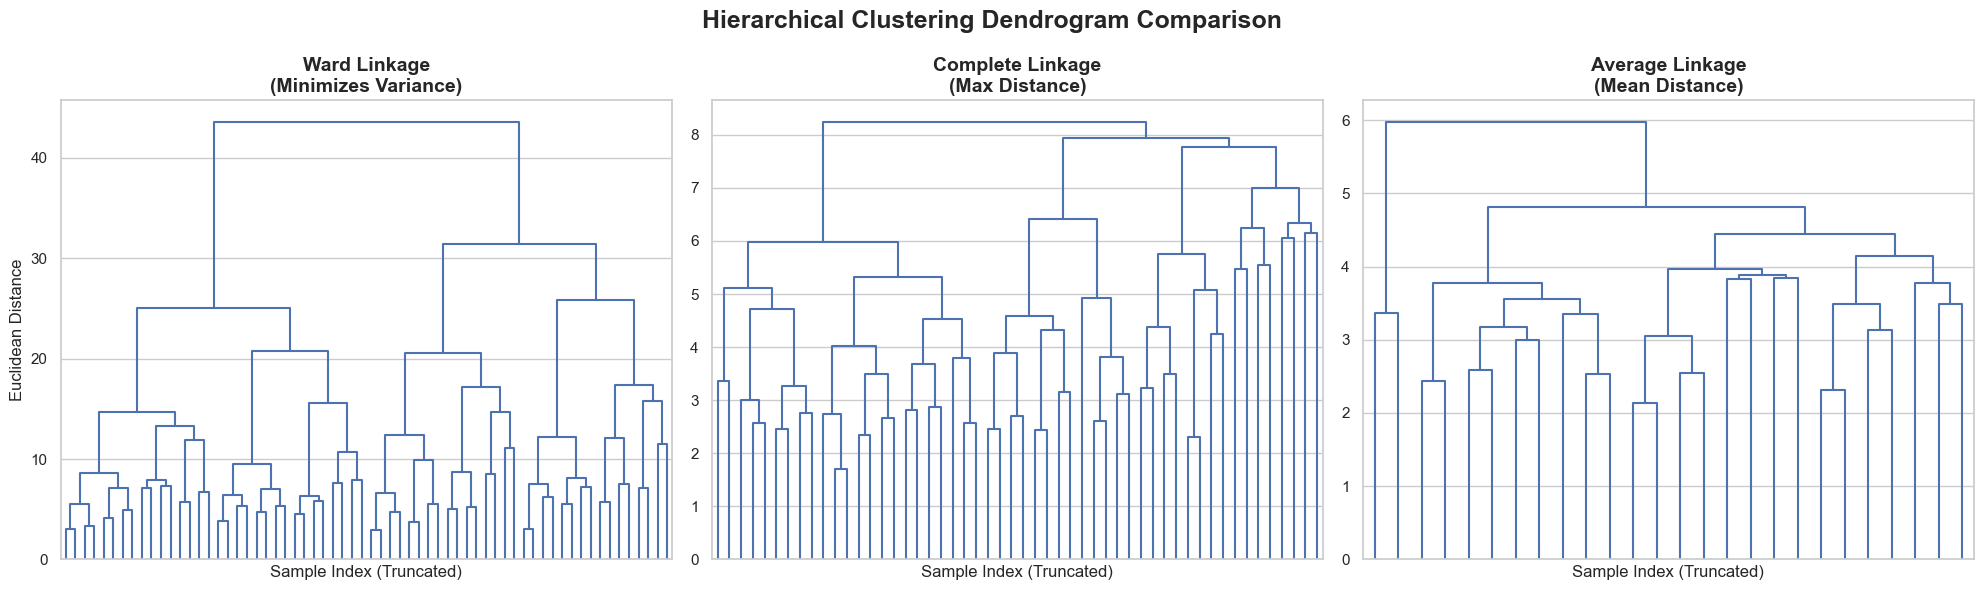


--- HOW TO INTERPRET THESE DENDROGRAMS ---
1. Look at the 'Ward Linkage' plot, as it mirrors K-Means' variance-minimization objective.
2. Imagine drawing a horizontal line that intersects the tallest vertical lines without crossing horizontal branches.
3. The number of vertical lines intersected validates your optimal K. Does it align with K=2?


In [79]:
import scipy.cluster.hierarchy as sch
# ── Step 2.5: Hierarchical Clustering & Dendrograms ──────────
# BUSINESS & COMPUTATIONAL LOGIC:
# Hierarchical clustering distance matrices require massive memory. 
# Running it on the full dataset might crash the kernel.
# We take a representative random sample (e.g., 1000 records) from 
# our full dataset to visualize the natural tree structure and 
# validate our chosen K from the Elbow/Silhouette methods.
# ─────────────────────────────────────────────────────────────
OPTIMAL_K = best_k
# 1. Safely sample the data (ensure we exclude target/cluster labels if they exist)
sample_size = min(1000, len(X_cluster))
cols_to_drop = [col for col in ['Cluster', 'Exited'] if col in X_cluster.columns]
X_sample = X_cluster.drop(columns=cols_to_drop).sample(n=sample_size, random_state=42)

# 2. Compute the linkage matrices across different methods
# 'ward' minimizes intra-cluster variance (aligns perfectly with K-Means logic)
# 'complete' considers the maximum distance between clusters
# 'average' considers the average distance between clusters
print("Computing linkage matrices. This may take a moment...")
linkage_ward = sch.linkage(X_sample, method='ward')
linkage_complete = sch.linkage(X_sample, method='complete')
linkage_average = sch.linkage(X_sample, method='average')

# 3. Visualize the Dendrograms side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot Ward
sch.dendrogram(linkage_ward, ax=axes[0], truncate_mode='level', p=5, no_labels=True, color_threshold=0)
axes[0].set_title('Ward Linkage\n(Minimizes Variance)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Euclidean Distance')
axes[0].set_xlabel('Sample Index (Truncated)')

# Plot Complete
sch.dendrogram(linkage_complete, ax=axes[1], truncate_mode='level', p=5, no_labels=True, color_threshold=0)
axes[1].set_title('Complete Linkage\n(Max Distance)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sample Index (Truncated)')

# Plot Average
sch.dendrogram(linkage_average, ax=axes[2], truncate_mode='level', p=5, no_labels=True, color_threshold=0)
axes[2].set_title('Average Linkage\n(Mean Distance)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Sample Index (Truncated)')

fig.suptitle('Hierarchical Clustering Dendrogram Comparison', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Interpretation Guide for the Notebook ────────────────────
print("\n--- HOW TO INTERPRET THESE DENDROGRAMS ---")
print("1. Look at the 'Ward Linkage' plot, as it mirrors K-Means' variance-minimization objective.")
print("2. Imagine drawing a horizontal line that intersects the tallest vertical lines without crossing horizontal branches.")
print(f"3. The number of vertical lines intersected validates your optimal K. Does it align with K={OPTIMAL_K}?")

## Use DBSCAN to identify outlier profiles and noise points within the data

In [80]:
# ── Step 3: DBSCAN Noise Filter ─────────────────────────────
# BUSINESS LOGIC: DBSCAN identifies density-based outliers
# (noise points labeled -1). These are customers whose
# behavioral/financial profiles do NOT fit any natural cluster.
# They are strong anomaly candidates for Phase 4.
#
# By removing noise BEFORE K-Means, we prevent outliers from
# distorting the centroids and producing misleading segments.
# ─────────────────────────────────────────────────────────────

dbscan = DBSCAN(eps=3.0, min_samples=10)
noise_labels = dbscan.fit_predict(X_cluster)

# Identify noise indices (label == -1)
noise_mask = noise_labels == -1
noise_indices = X_cluster.index[noise_mask].tolist()

print(f'Total data points          : {len(X_cluster)}')
print(f'DBSCAN noise points found  : {len(noise_indices)}')
print(f'Non-noise (core/border)    : {(~noise_mask).sum()}')

# Save noise indices for Phase 4 anomaly detection
dbscan_noise_indices = noise_indices  # variable preserved for later phases

# Filter noise OUT of the main dataset
X_clean = X_cluster[~noise_mask].reset_index(drop=True)
y_clean = y_exited[~noise_mask].reset_index(drop=True)

print(f'\nClean dataset shape after noise removal: {X_clean.shape}')
print(f'Noise indices saved to `dbscan_noise_indices` for Phase 4.')


Total data points          : 10000
DBSCAN noise points found  : 0
Non-noise (core/border)    : 10000

Clean dataset shape after noise removal: (10000, 11)
Noise indices saved to `dbscan_noise_indices` for Phase 4.


## Profile each cluster: describe the entity type it represents and its distinguishing characteristics

In [81]:
# ── Step 4: Final K-Means on clean (noise-free) data ────────
OPTIMAL_K = best_k  # from Step 2 analysis

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42,
                      n_init=10, max_iter=300)
cluster_labels = kmeans_final.fit_predict(X_clean)

# Attach cluster labels to clean data
X_clean['Cluster'] = cluster_labels

final_sil = silhouette_score(
    X_clean.drop(columns=['Cluster']), cluster_labels
)
print(f'Final K-Means with K={OPTIMAL_K}')
print(f'Silhouette Score on clean data: {final_sil:.4f}')
print(f'Cluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index()}')


Final K-Means with K=2
Silhouette Score on clean data: 0.1527
Cluster distribution:
0    5908
1    4092
Name: count, dtype: int64


## Deliverable: Cluster profiles with full business interpretation

CLUSTER BUSINESS PROFILES
         Size  Churn_Rate_%  CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Gender_Male    Exited
Cluster                                                                                                                                                                                     
0        5908         22.38     0.008516  0.016915 -0.015429  0.737758      -0.394449   0.701591        0.516080         0.012181           0.393534         0.198375     0.553825  0.223764
1        4092         17.47    -0.012296 -0.024421  0.022276 -1.065169       0.569502   0.711144        0.513685        -0.017587           0.044966         0.318915     0.533969  0.174731



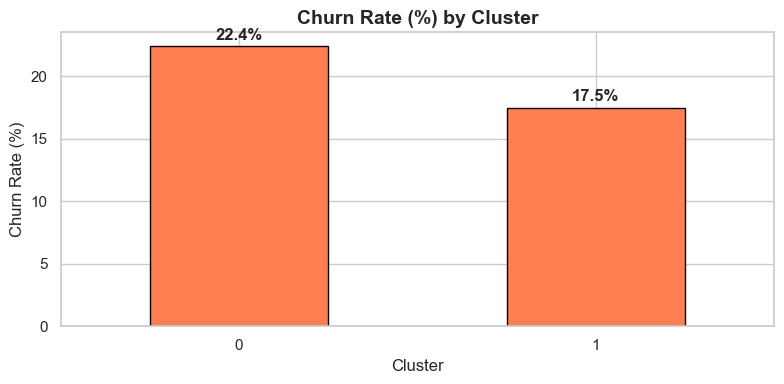

In [82]:
# ── Step 5: Business Profiling ───────────────────────────────
# Merge cluster labels AND Exited back onto the clean dataset,
# then compute per-cluster feature means and churn rate.

# Merge Exited back
X_clean['Exited'] = y_clean.values

# Group by cluster and compute mean of all features
profile = X_clean.groupby('Cluster').mean()

# Calculate exact churn rate per cluster
churn_rate = (
    X_clean.groupby('Cluster')['Exited']
    .mean()
    .mul(100)
    .round(2)
    .rename('Churn_Rate_%')
)

# Cluster size
cluster_size = (
    X_clean.groupby('Cluster').size().rename('Size')
)

# Build the summary table
summary = pd.concat([cluster_size, churn_rate, profile], axis=1)

print('=' * 80)
print('CLUSTER BUSINESS PROFILES')
print('=' * 80)
print(summary.to_string())
print('\n' + '=' * 80)

# ── Visual: Churn rate by cluster ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
churn_rate.plot(kind='bar', color='coral', edgecolor='black', ax=ax)
ax.set_title('Churn Rate (%) by Cluster', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(churn_rate.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
